In [1]:
import numpy as np
import pandas as pd
from src.health_analyzer import HealthAnalyzer
np.random.seed(42)

### 1. Initiering och strukturering

In [2]:
analyzer = HealthAnalyzer('data/health_study_dataset.csv')
analyzer.show_info()

--- Dataöversikt ---
   id  age sex  height  weight  systolic_bp  cholesterol smoker  disease
0   1   57   F   168.9    65.8        141.8         4.58     No        0
1   2   47   M   180.4    95.9        144.8         5.18    Yes        0
2   3   59   F   169.9    82.2        151.7         6.16     No        0
3   4   72   M   157.7    93.1        151.0         6.63     No        0
4   5   46   M   192.6   104.1        144.1         5.21     No        0

--- Datainformation ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    

### 2. Analys från Del 1


--- Deskriptiv Statistik ---
          age  weight  height  systolic_bp  cholesterol
mean    49.43   73.41  171.85       149.18         4.93
median  50.00   73.20  171.35       149.40         4.97
min     18.00   33.70  144.40       106.80         2.50
max     90.00  114.40  200.40       185.90         7.88


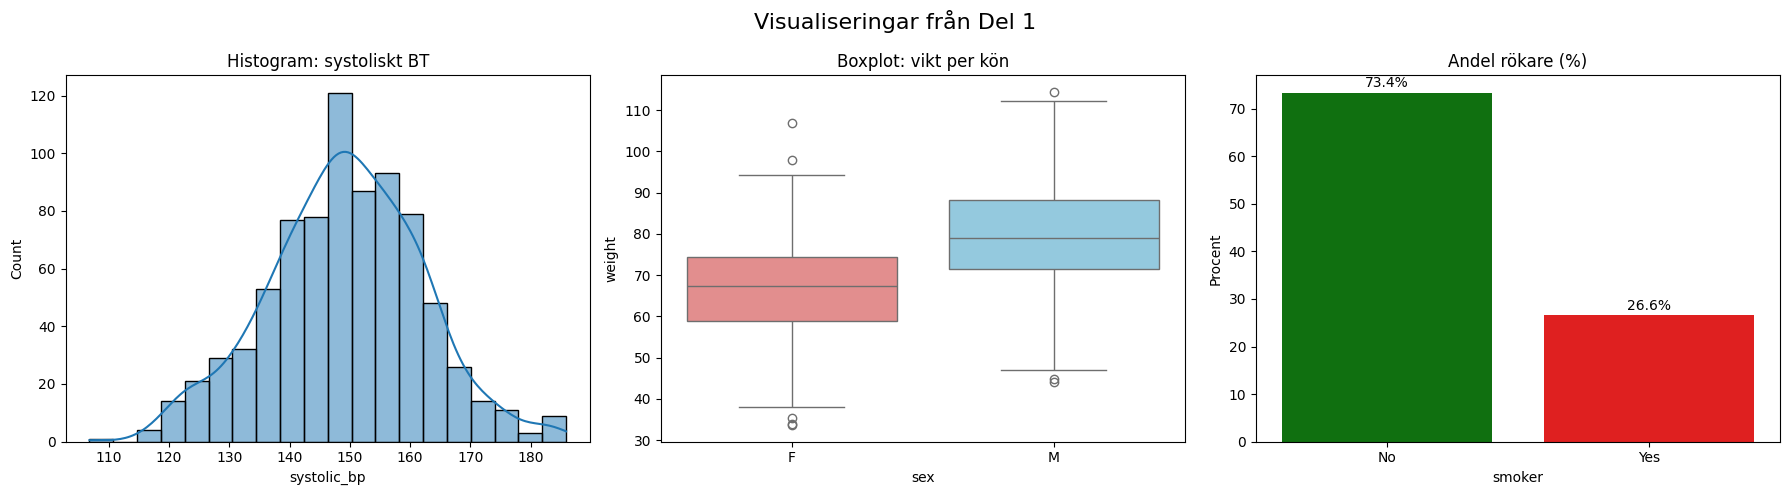


--- Hypotesprövning (Rökare vs BT) ---
Medelvärde rökare: 149.52
Medelvärde icke-rökare: 149.05
T-statistik: 0.4503
P-värde (ensidigt): 0.3264
Slutsats: ingen signifikant skillnad (behåll H0).


In [3]:
analyzer.calculate_descriptive_stats()
analyzer.plot_part1_visualizations()
analyzer.test_smoker_hypothesis()

### Korrelationsanalys
Vi ritar en korrelationsmatris (heatmap) för att hitta linjära samband mellan variabler. 

Detta visar att det finns ett visst samband mellan ålder och systoliskt blodtryck.

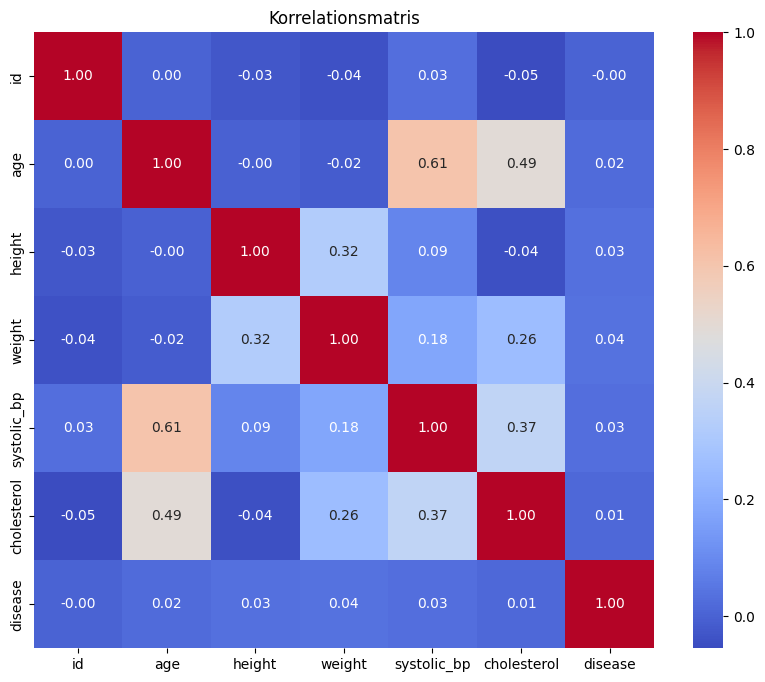

In [4]:
analyzer.plot_correlation_matrix()

### Linjär Regression
Formel: $\text{Systoliskt BT} = \hat{a} + \hat{b} \times \text{ålder}$


--- Regression (features: ['age']) ---
R²: 0.3692
MSE: 103.1219
Intercept: 122.6849
Koefficient (age): 0.5360


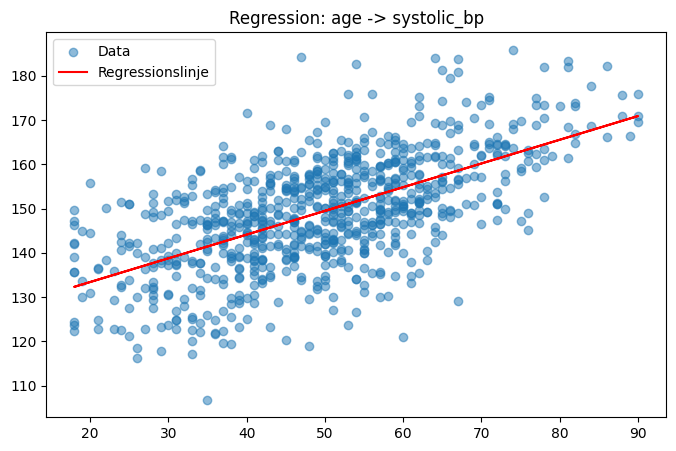

In [5]:
analyzer.perform_regression(['age'], 'systolic_bp')

### Multipel Regression
För att få en mer utvecklad klass och en mer avancerad modell använder vi multipel regression.

Detta bör ge en bättre förklaring ($R^2$) än att enbart använda ålder.

In [6]:
features = ['age', 'weight', 'cholesterol']
target = 'systolic_bp'
analyzer.perform_regression(features, target)


--- Regression (features: ['age', 'weight', 'cholesterol']) ---
R²: 0.4058
MSE: 97.1279
Intercept: 108.5107
Koefficient (age): 0.5264
Koefficient (weight): 0.1706
Koefficient (cholesterol): 0.4315


### Utökad Analys: jämförelse av sjukdomsfrekvens
Vi undersöker om det finns en statistiskt säkerställd skillnad i andelen sjuka mellan män och kvinnor med hjälp av ett z-test för andelar.


--- Proportionstest: Sjukdomsfrekvens (sex: F vs M) ---
Andel sjuka F: 18/403 (4.47%)
Andel sjuka M: 29/397 (7.30%)
Skillnad (F - M): -0.028 i andel
Z-statistik: -1.7069
Tvåsidigt P-värde: 0.0878
Slutsats: Ingen signifikant skillnad påvisades.


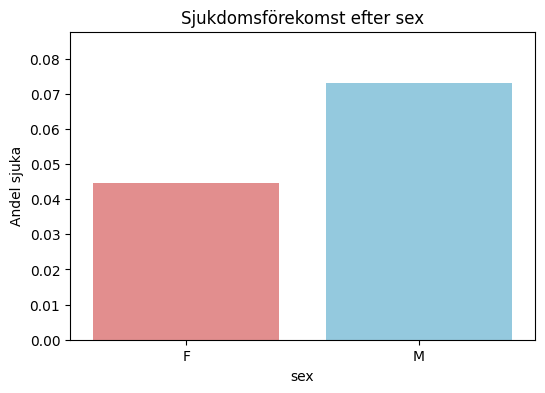

In [7]:
analyzer.test_disease_proportion(group_col='sex')

## Metodval och motivering

### 1. Objektorienterad Programmering (OOP)
Jag har valt att kapsla in all logik i klassen `HealthAnalyzer` och dess metoder. 
**Motivering:** Detta skapar en ren och återanvändbar pipeline där datan (`self.df`) hanteras centralt. Att flytta kod från Notebook till en `src` modul uppfyller kraven på struktur och moduler.

### 2. Linjär Regression (scikit-learn)
**Motivering:** Även om man kan implementera regressionsmatematiken manuellt (normalekvationen), är det bättre att använda `scikit-learn` då det är optimerat, hanterar datastrukturer och är standard i branschen.

### 3. Utökad Analys (proportionstest)
**Motivering:** Istället för enbart att rita en ny graf, valdes ett z-test för proportioner (`proportions_ztest`) för att testa en ny hypotes (sjukdomsfrekvens vs kön). Detta ger en djupare statistisk insikt i en kategorisk-mot-binär relation.

**Källor:** 
* Scikit-learn Dokumentation för [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).
* Statsmodels Dokumentation för [proportions_ztest](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html).
* Joakims YouTube videor.